# Train SASRecf

In [6]:
import numpy as np

# For NumPy 2.0 compatibility with RecBole 1.2
np.float_ = np.float64
np.int_ = np.int64
np.complex_ = np.complex128
np.unicode_ = np.str_

In [2]:
from typing import Any
import torch
import pandas as pd
from recbole.config import Config
from recbole.data.dataloader import FullSortEvalDataLoader
from recbole.data import create_dataset, data_preparation
from recbole.model.sequential_recommender import SASRec, SASRecF
from recbole.trainer import Trainer
from recbole.utils import init_seed

In [3]:
# --- Config ---
# Assume we have `*.train.inter`, `*.valid.inter`, `*.test.inter`
DATASET_NAME: str = "Beauty_and_Personal_Care" 
DATA_DIR: str = "../data"
SEED = 67

# Sequential recommendation config
MAX_ITEM_LIST_LENGTH: int = 50

## Create dataset

In [4]:
init_seed(SEED, reproducibility=True)

In [7]:
config_dict: dict[str, Any] = {
    "data_path": DATA_DIR,
    "dataset": DATASET_NAME,
    "USER_ID_FIELD": "user_id",
    "ITEM_ID_FIELD": "item_id",
    "RATING_FIELD": "rating",
    "TIME_FIELD": "timestamp",
    "benchmark_filename": ["train", "valid", "test"],
    "load_col": {
        "inter": ["user_id", "item_id", "rating", "timestamp", "item_id_list"],
        "user": ["user_id", "category"],
        "item": ["item_id", "title"],
    },
    # This is needed to tell RecBole that `item_id_list` is an alias of `item_id` for sequential recommendation.
    "alias_of_item_id": ["item_id_list"],
    "selected_features": ["title"],
    "MAX_ITEM_LIST_LENGTH": MAX_ITEM_LIST_LENGTH,
    "epochs": 1,
    "train_batch_size": 512,
    "eval_batch_size": 512,
    "train_neg_sample_args": None,
    "eval_args": {
        # Split is already determined by the `benchmark filename` as separate `.inter` files
        "split": None, 
        "order": "TO",
        "mode": "full",
    },
    "metrics": ["NDCG", "Recall", "MRR"],
    "valid_metric": "NDCG@10",
    "seed": SEED,
}

config: Config = Config(model="SASRecF", config_dict=config_dict)

# Use MPS if available (for Apple Silicon)
if torch.backends.mps.is_available():
    print("Configuring MPS (Apple Silicon GPU) for training.")
    config.final_config_dict["device"] = torch.device("mps")

dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

Configuring MPS (Apple Silicon GPU) for training.


/Users/yudhistiraonggowarsito/Documents/SMU/Courses/CS608 - Recommender Systems/grp_project/yc-code/amazon-item-recommender/.venv/lib/python3.12/site-packages/recbole/data/dataset/dataset.py:501: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[field].fillna(value="", inplace=True)
/Users/yudhistiraonggowarsito/Documents/SMU/Courses/CS608 - Recommender Systems/grp_project/yc-code/amazon-item-recommender/.venv/lib/python3.12/site-packages/recbole/data/dataset/dataset.py:501: FutureWarning: A value is trying to be set on a copy 

## Train SASRecf

In [9]:
model: SASRecF = SASRecF(config, train_data.dataset).to(config["device"])
trainer: Trainer = Trainer(config, model)

In [ ]:
best_valid_score: float
best_valid_result: dict[str, float]
best_valid_score, best_valid_result = trainer.fit(train_data, valid_data, verbose=True, show_progress=True)

Train     0:   0%|                                                          | 0/126 [00:00<?, ?it/s]/Users/yudhistiraonggowarsito/Documents/SMU/Courses/CS608 - Recommender Systems/grp_project/yc-code/amazon-item-recommender/.venv/lib/python3.12/site-packages/recbole/trainer/trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|██████████████████████████████████████████████████| 18/18 [00:36<00:00,  2.03s/it]


In [13]:
import gc

# Clear Python's garbage collector
gc.collect()

# Clear the MPS memory pool
torch.mps.empty_cache()

In [11]:
with torch.no_grad():
    trainer.evaluate(test_data, load_best_model=True, show_progress=True)

Evaluate   : 100%|██████████████████████████████████████████████████| 18/18 [00:40<00:00,  2.25s/it]


In [13]:
# print(f"\nBest valid score: {best_valid_score:.4f}")
print("Best valid result:")
for metric, score in best_valid_result.items():
    print(f"  {metric}: {score:.4f}")

Best valid result:


NameError: name 'best_valid_result' is not defined

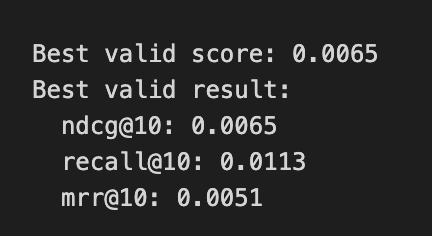

## Evaluate on test set

In [14]:
test_result: dict[str, float] = trainer.evaluate(test_data)

print("Test results (Overall):")
for metric, value in test_result.items():
    print(f"  {metric}: {value:.4f}")

Test results (Overall):
  ndcg@10: 0.0035
  recall@10: 0.0063
  mrr@10: 0.0026


In [15]:
# Map integer categories to labels
tok = dataset.field2token_id["category"]
CAT_LABELS = {tok["0"]: "warm", tok["1"]: "cold", tok["2"]: "new"}

uid_to_cat = dict(zip(
    dataset.user_feat[dataset.uid_field].numpy(),
    dataset.user_feat["category"].numpy(),
))

test_inter = test_data.dataset.inter_feat
uid_array = test_inter[dataset.uid_field].numpy()

for cat_id, cat_label in CAT_LABELS.items():
    cat_uids = {uid for uid, c in uid_to_cat.items() if c == cat_id}
    mask = np.isin(uid_array, list(cat_uids))
    if not mask.any():
        print(f"\n  {cat_label}: no users in test set — skipping")
        continue

    cat_ds = test_data.dataset.copy(test_inter[mask])
    cat_dl = FullSortEvalDataLoader(config, cat_ds, sampler=None, shuffle=False)
    results = trainer.evaluate(cat_dl)
    print(f"\nTest results ({cat_label}):")
    print(f"  Interactions: {mask.sum()}")
    for metric, val in results.items():
        print(f"  {metric}: {val:.4f}")


Test results (warm):
  Interactions: 4495
  ndcg@10: 0.0024
  recall@10: 0.0049
  mrr@10: 0.0016

Test results (cold):
  Interactions: 2678
  ndcg@10: 0.0036
  recall@10: 0.0067
  mrr@10: 0.0027

Test results (new):
  Interactions: 2016
  ndcg@10: 0.0057
  recall@10: 0.0089
  mrr@10: 0.0048


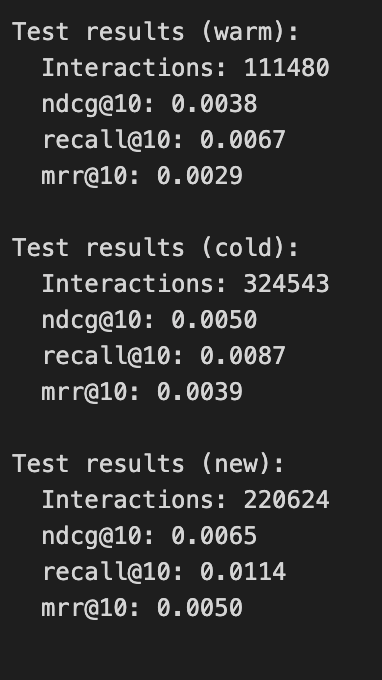